# Import libraries and load text

In [1]:
import sys
!{sys.executable} -m pip install nltk pandas numpy plotly scikit-learn

import nltk
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /Users/domin/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /Users/domin/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /Users/domin/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /Users/domin/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [2]:
import pandas as pd
import numpy as np
import nltk
from nltk.corpus import stopwords
from nltk import word_tokenize, FreqDist
from nltk.stem.wordnet import WordNetLemmatizer
import string
import plotly
import plotly.graph_objects as go
import plotly.express as px
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer

In [3]:
# Prepping dataframe as done in 1_EDA.ipynb

df = pd.read_csv('../data/complaints.csv')
df = df[['Product', 'Consumer complaint narrative']]
df = df.rename(columns={"Product": "product", "Consumer complaint narrative": "narrative"})
df['product'] = df['product'].astype(str).replace({'Credit reporting, credit repair services, or other personal consumer reports': 'credit_reporting',
                       'Debt collection': 'debt_collection',
                       'Credit card or prepaid card': 'credit_card',
                       'Mortgage': 'mortgages_and_loans',
                       'Checking or savings account': 'retail_banking',
                       'Money transfer, virtual currency, or money service': 'retail_banking',
                       'Vehicle loan or lease': 'mortgages_and_loans',
                       'Payday loan, title loan, or personal loan': 'mortgages_and_loans',
                       'Student loan': 'mortgages_and_loans'})

In [4]:
df.head()

,product,narrative
0,credit_reporting,NaN
1,credit_reporting,These are not my accounts.
2,credit_reporting,"I wrote three requests, the unverified account..."
3,credit_reporting,NaN
4,credit_reporting,I was recently going to check out a new car at...


In [5]:
df.loc[2]['narrative']

'I wrote three requests, the unverified accounts listed below still remain on my credit report in violation of Federal Law. Equifax is under FCRA law to obtain the of the original creditors documentation on file to verify that this information is mine and is correct. I have already filed a FTC Report and Police Report. Who verified these accounts? You have NOT provided me a copy of ANY original documentation ( a consumer contract with my signature on it ) as required under Section 609 ( a ) ( 1 ) ( A ) & Section 611 ( a ) ( 1 ) ( A ). Furthermore you have failed to provide the method of verification as required under Section 611 ( a ) ( 7 ). Please be advised that under Section 611 ( 5 ) ( A ) of the FCRA you are required to promptly DELETE all information which can not be verified. \nThe law is very clear as to the Civil liability and the remedy available to me ( Section 616 & 617 ) if you fail to comply with Federal Law. I am a litigious consumer and fully intend on pursuing litigati

In [6]:
len(df)

475518

# Loop through narratives to remove stopwords, tokenize and lemmatize

In [7]:
stopwords_list = stopwords.words('english') + list(string.punctuation)
stopwords_list += ["''", '""', '...', '``']
stopwords_list += ['--', 'xxxx']

In [8]:
# function to tokenize data and remove stopwords
def process_narrative(narrative):
    tokens = nltk.word_tokenize(narrative)
    stopwords_removed = [token.lower() for token in tokens if token.lower() not in stopwords_list]
    
    # adding line to remove all tokens with numbers and punctuation
    stopwords_punc_and_numbers_removed = [word for word in stopwords_removed if word.isalpha()]
    
    return stopwords_punc_and_numbers_removed


# function to concat words (used in function below)
def concat_words(list_of_words):
    # remove any NaN's
    # list_of_words = [i for i in list if i is not np.nan]

    concat_words = ''
    for word in list_of_words:
        concat_words += word + ' '
    return concat_words.strip()

# function to lemmatize words and merge each complaint into a single space-separated string

lemm = WordNetLemmatizer()

def make_lemma_and_concat(list_of_words):
    # remove any NaN's
    list_of_words = [i for i in list_of_words if i is not np.nan]
    
    # lemmatize each word
    lemmatized_list = []
    for idx, word in enumerate(list_of_words):
        lemmatized_list.append(lemm.lemmatize(word))
    
    # make the list into a single string with the words separated by ' '
    concatenated_string = concat_words(lemmatized_list)
    return concatenated_string

# Prepare dataframe for modeling

In [9]:
def process_and_lemmatize(narrative):
    if pd.notna(narrative):
        processed_narr = process_narrative(narrative)
        return make_lemma_and_concat(processed_narr)
    return narrative

df['narrative'] = df['narrative'].apply(process_and_lemmatize)


# Save dataframe as csv for use in other notebooks

In [ ]:
df = df.drop_duplicates()
df = df[df['narrative'].notna()]
df.to_csv('../data/complaints_processed_full.csv', index=False)


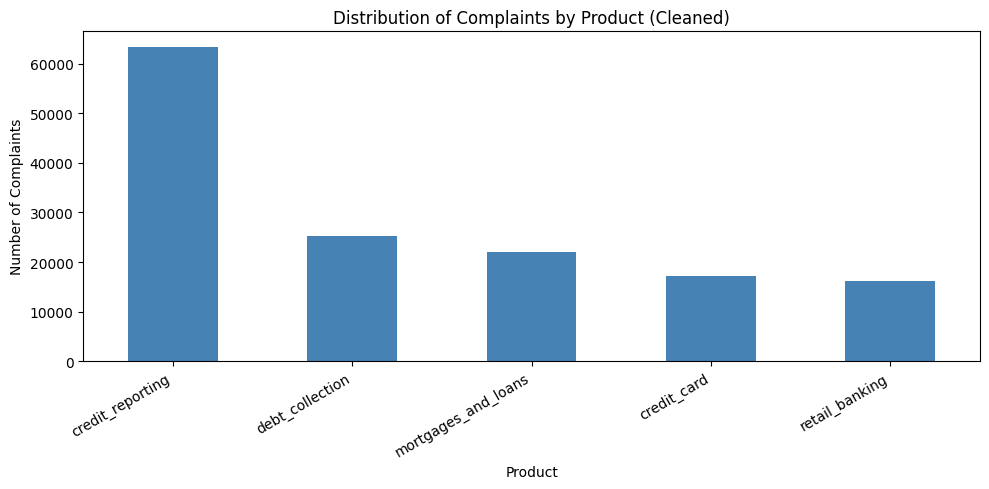

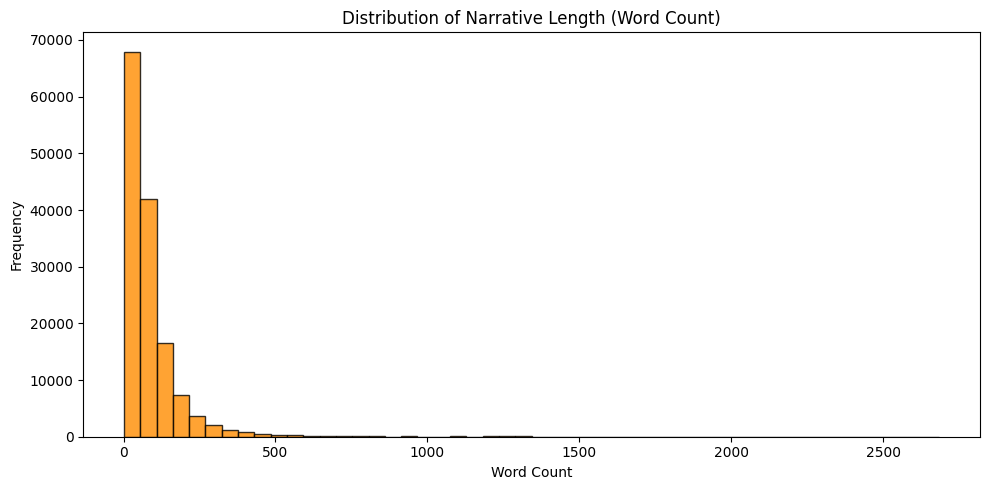

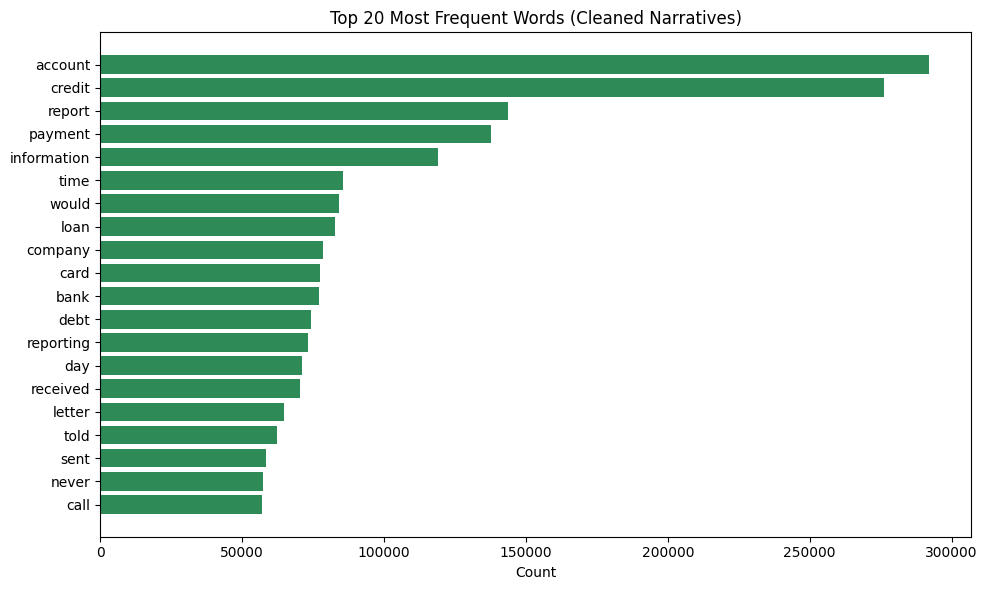

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

# Load the cleaned output you just exported
clean_df = pd.read_csv("../data/complaints_processed_full.csv")

# Optional: create a derived feature for text length
clean_df["word_count"] = clean_df["narrative"].fillna("").str.split().str.len()

# 1) Product distribution (bar chart)
product_counts = clean_df["product"].value_counts()
plt.figure(figsize=(10, 5))
product_counts.plot(kind="bar", color="steelblue")
plt.title("Distribution of Complaints by Product (Cleaned)")
plt.xlabel("Product")
plt.ylabel("Number of Complaints")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

# 2) Narrative length distribution (histogram)
plt.figure(figsize=(10, 5))
plt.hist(clean_df["word_count"], bins=50, color="darkorange", edgecolor="black", alpha=0.8)
plt.title("Distribution of Narrative Length (Word Count)")
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# 3) Top 20 most frequent words in cleaned narratives
all_tokens = " ".join(clean_df["narrative"].dropna()).split()
top_words = Counter(all_tokens).most_common(20)
words, counts = zip(*top_words)

plt.figure(figsize=(10, 6))
plt.barh(words[::-1], counts[::-1], color="seagreen")
plt.title("Top 20 Most Frequent Words (Cleaned Narratives)")
plt.xlabel("Count")
plt.tight_layout()
plt.show()

/var/folders/5z/_v91q0bs3cl_y08k407bg0t00000gn/T/ipykernel_95263/2209619480.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_for_box, labels=order, showfliers=False)


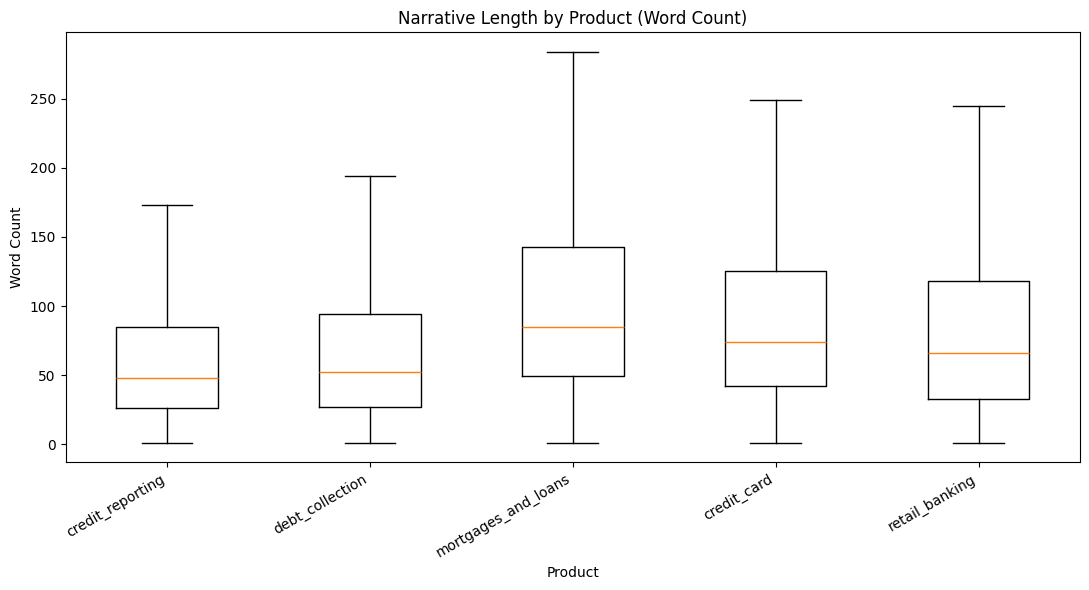

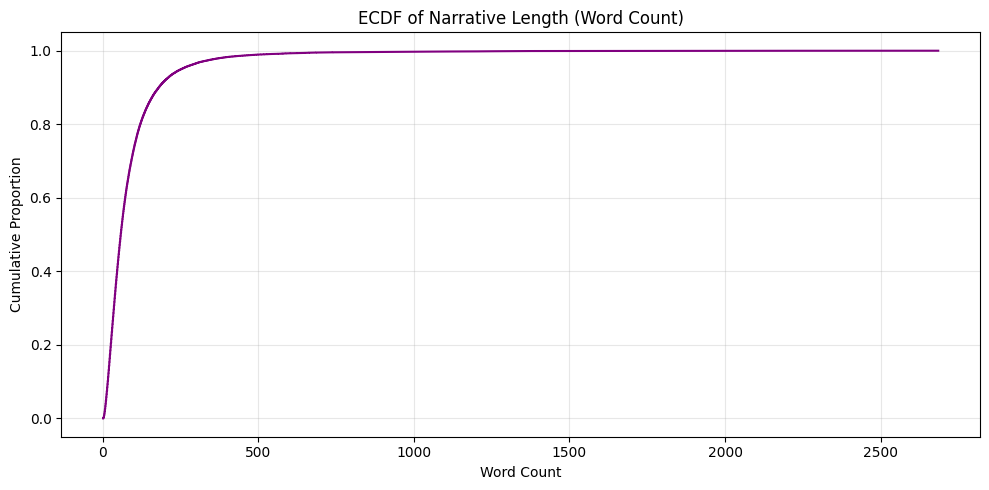

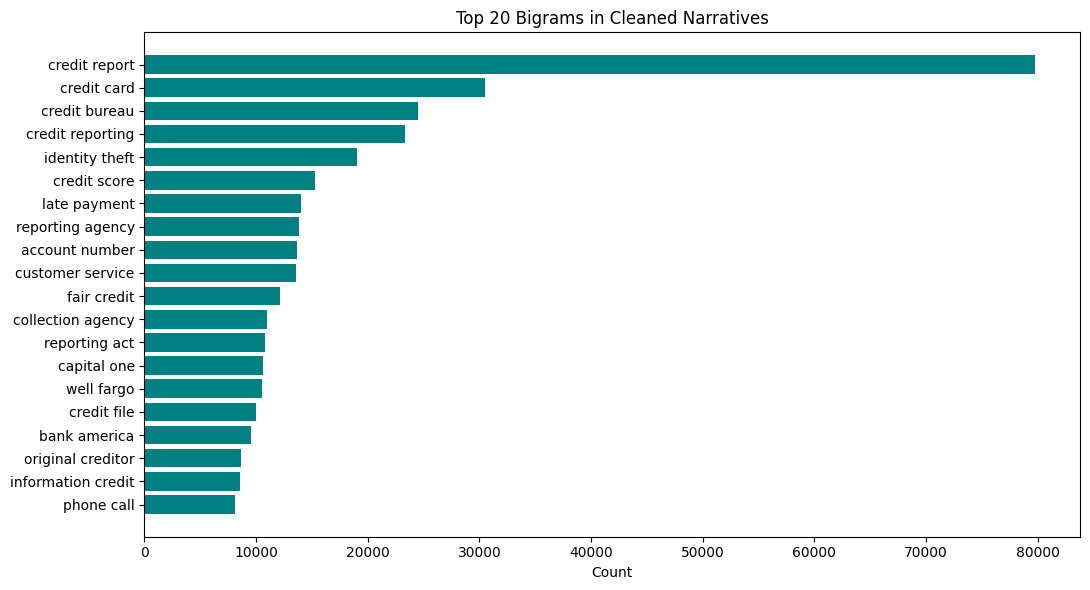

In [2]:
# Additional useful distribution plots for cleaned data
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer

# Ensure derived features exist
clean_df = pd.read_csv("../data/complaints_processed_full.csv")
clean_df["word_count"] = clean_df["narrative"].fillna("").str.split().str.len()

# 4) Boxplot: narrative length by product (reveals spread + outliers by class)
order = clean_df["product"].value_counts().index.tolist()
plt.figure(figsize=(11, 6))
data_for_box = [clean_df.loc[clean_df["product"] == p, "word_count"] for p in order]
plt.boxplot(data_for_box, labels=order, showfliers=False)
plt.title("Narrative Length by Product (Word Count)")
plt.xlabel("Product")
plt.ylabel("Word Count")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

# 5) ECDF: cumulative distribution of word counts (shows percentile behavior)
x = np.sort(clean_df["word_count"].values)
y = np.arange(1, len(x) + 1) / len(x)
plt.figure(figsize=(10, 5))
plt.plot(x, y, color="purple")
plt.title("ECDF of Narrative Length (Word Count)")
plt.xlabel("Word Count")
plt.ylabel("Cumulative Proportion")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 6) Top 20 bigrams in cleaned narratives (captures common two-word themes)
vec = CountVectorizer(ngram_range=(2, 2), min_df=20)
X = vec.fit_transform(clean_df["narrative"].fillna(""))
bigram_counts = np.asarray(X.sum(axis=0)).ravel()
bigram_terms = np.array(vec.get_feature_names_out())
top_idx = np.argsort(bigram_counts)[-20:]
top_terms = bigram_terms[top_idx]
top_vals = bigram_counts[top_idx]

plt.figure(figsize=(11, 6))
plt.barh(top_terms, top_vals, color="teal")
plt.title("Top 20 Bigrams in Cleaned Narratives")
plt.xlabel("Count")
plt.tight_layout()
plt.show()